In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dstevenson/synthetic-delay-dataset-2017-xlsx/synthetic_delay_dataset_2017.xlsx


In [28]:
import pandas as pd
import numpy as np

df = pd.read_excel('/kaggle/input/datasets/dstevenson/synthetic-delay-dataset-2017-v2-xlsx/synthetic_delay_dataset_2017_v2.xlsx', sheet_name='delay_data')

print(df.shape)
print(df.dtypes)
print(df['has_delay'].value_counts(normalize=True))

(200750, 23)
date                      object
day_of_week                int64
is_weekend                 int64
is_holiday                 int64
season                    object
hour                       int64
peak_type                 object
station_code               int64
station_name_en           object
station_name_kr           object
line_num                   int64
latitude                 float64
longitude                float64
district                  object
scheduled_time            object
actual_time               object
weather_condition         object
temperature_C            float64
precipitation_mm         float64
real_flow_pattern_ref    float64
delay_minutes            float64
has_delay                  int64
is_synthetic                bool
dtype: object
has_delay
0    0.799452
1    0.200548
Name: proportion, dtype: float64


In [29]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [
    'station_code', 'line_num', 'hour', 'day_of_week', 'is_weekend',
    'is_holiday', 'season', 'weather_condition', 'temperature_C',
    'precipitation_mm', 'real_flow_pattern_ref', 'latitude', 'longitude'
]
target_col = 'has_delay'

data = df[feature_cols + [target_col]].copy()

# Encode categorical text columns
le_season = LabelEncoder()
data['season'] = le_season.fit_transform(data['season'])

le_weather = LabelEncoder()
data['weather_condition'] = le_weather.fit_transform(data['weather_condition'])

X = data[feature_cols]
y = data[target_col]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train delay rate:", y_train.mean(), "Test delay rate:", y_test.mean())

Train: (160600, 13) Test: (40150, 13)
Train delay rate: 0.20054794520547944 Test delay rate: 0.20054794520547944


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_delay = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_delay.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=150,
                       n_jobs=-1, random_state=42)

In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = rf_delay.predict(X_test)
y_proba = rf_delay.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7058779576587796
Precision: 0.3602618463140668
Recall: 0.601465474416294
F1 Score: 0.4506164224238195
ROC-AUC: 0.7331495034596143

Confusion Matrix:
[[23498  8600]
 [ 3209  4843]]

              precision    recall  f1-score   support

           0       0.88      0.73      0.80     32098
           1       0.36      0.60      0.45      8052

    accuracy                           0.71     40150
   macro avg       0.62      0.67      0.62     40150
weighted avg       0.78      0.71      0.73     40150



real_flow_pattern_ref    0.405149
weather_condition        0.103793
station_code             0.103167
temperature_C            0.079842
precipitation_mm         0.076513
day_of_week              0.047953
longitude                0.044786
latitude                 0.044085
is_weekend               0.028955
line_num                 0.027554
season                   0.019478
hour                     0.010773
is_holiday               0.007953
dtype: float64


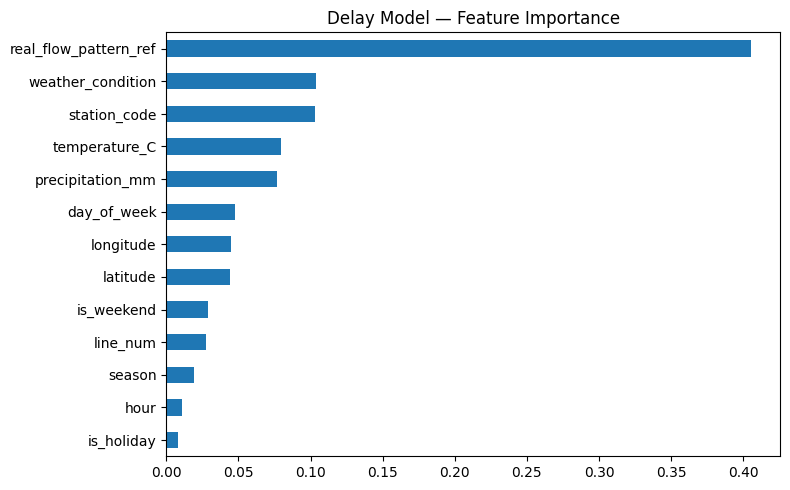

In [33]:
import matplotlib.pyplot as plt

importances = pd.Series(rf_delay.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title('Delay Model — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [8, 12, 16, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist, n_iter=25, scoring='roc_auc',
    cv=3, random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)
print(search.best_params_, search.best_score_)
best_rf = search.best_estimator_

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8} 0.7322155295558233


In [39]:
best_rf_v2 = search.best_estimator_
y_pred_v2 = best_rf_v2.predict(X_test)
y_proba_v2 = best_rf_v2.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("ROC-AUC:", roc_auc_score(y_test, y_proba_v2))
print(confusion_matrix(y_test, y_pred_v2))
print(classification_report(y_test, y_pred_v2))

ROC-AUC: 0.7362048702252728
[[22140  9958]
 [ 2778  5274]]
              precision    recall  f1-score   support

           0       0.89      0.69      0.78     32098
           1       0.35      0.65      0.45      8052

    accuracy                           0.68     40150
   macro avg       0.62      0.67      0.61     40150
weighted avg       0.78      0.68      0.71     40150



In [40]:
import joblib

joblib.dump(best_rf_v2, 'delay_prediction_rf_v2.pkl', compress=3)
joblib.dump(le_season, 'le_season.pkl')
joblib.dump(le_weather, 'le_weather.pkl')

print("Saved: delay_prediction_rf_v2.pkl")

Saved: delay_prediction_rf_v2.pkl


In [41]:
import os
size_kb = os.path.getsize('delay_prediction_rf_v2.pkl') / 1024
print(f"Model size: {size_kb:.1f} KB")

Model size: 3493.5 KB


In [38]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred = rf_delay.predict(X_test)
y_proba = rf_delay.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7058779576587796
Precision: 0.3602618463140668
Recall: 0.601465474416294
F1 Score: 0.4506164224238195
ROC-AUC: 0.7331495034596143

Confusion Matrix:
[[23498  8600]
 [ 3209  4843]]

              precision    recall  f1-score   support

           0       0.88      0.73      0.80     32098
           1       0.36      0.60      0.45      8052

    accuracy                           0.71     40150
   macro avg       0.62      0.67      0.62     40150
weighted avg       0.78      0.71      0.73     40150



In [35]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
print("Best threshold:", thresholds[best_idx], "F1:", f1_scores[best_idx])

Best threshold: 0.5023100236508065 F1: 0.4508426961594881


In [36]:
import lightgbm as lgb
lgb_delay = lgb.LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=42)
lgb_delay.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 32208, number of negative: 128392
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1420
[LightGBM] [Info] Number of data points in the train set: 160600, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', n_estimators=300, random_state=42)

In [37]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

y_pred_lgb = lgb_delay.predict(X_test)
y_proba_lgb = lgb_delay.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:", recall_score(y_test, y_pred_lgb))
print("F1 Score:", f1_score(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))
print()
print(classification_report(y_test, y_pred_lgb))

Accuracy: 0.6840099626400996
Precision: 0.3448899002744127
Recall: 0.6399652260307997
F1 Score: 0.44822337233070936
ROC-AUC: 0.7331604106611282

Confusion Matrix:
[[22310  9788]
 [ 2899  5153]]

              precision    recall  f1-score   support

           0       0.89      0.70      0.78     32098
           1       0.34      0.64      0.45      8052

    accuracy                           0.68     40150
   macro avg       0.61      0.67      0.61     40150
weighted avg       0.78      0.68      0.71     40150



In [22]:
data['hour_sin'] = np.sin(2*np.pi*data['hour']/24)
data['hour_cos'] = np.cos(2*np.pi*data['hour']/24)

regression

In [24]:
delayed_df = df[df['has_delay'] == 1].copy()
print(delayed_df.shape)
print(delayed_df['delay_minutes'].describe())

(32198, 23)
count    32198.000000
mean         3.433036
std          3.363786
min          0.500000
25%          1.100000
50%          2.300000
75%          4.500000
max         37.200000
Name: delay_minutes, dtype: float64


In [25]:
delayed_df['season'] = le_season.transform(delayed_df['season'])
delayed_df['weather_condition'] = le_weather.transform(delayed_df['weather_condition'])

X_reg = delayed_df[feature_cols]
y_reg = delayed_df['delay_minutes']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_delay_minutes = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_delay_minutes.fit(X_reg_train, y_reg_train)

RandomForestRegressor(max_depth=10, n_estimators=150, n_jobs=-1,
                      random_state=42)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_reg_pred = rf_delay_minutes.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5
r2 = r2_score(y_reg_test, y_reg_pred)

print("MAE:", mae, "minutes")
print("RMSE:", rmse, "minutes")
print("R²:", r2)

MAE: 2.4093706855922647 minutes
RMSE: 3.3485102294543436 minutes
R²: 0.024662686720876126
